In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

e:\Important\Skills\digital-impact-on-teen-minds\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = "Student Mental health.csv"
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "shariful07/student-mental-health",
    file_path
)

C:\Users\zibsh\AppData\Local\Temp\ipykernel_29356\422904663.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [3]:
df.shape

(101, 11)

In [4]:
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [5]:
df.columns = [
    'timestamp',
    'gender',
    'age',
    'course',
    'year_of_study',
    'cgpa',
    'marital_status',
    'depression',
    'anxiety',
    'panic_attack',
    'treatment'
]

In [6]:
df.head()

,timestamp,gender,age,course,year_of_study,cgpa,marital_status,depression,anxiety,panic_attack,treatment
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [7]:
# remove timestamp column
df = df.drop('timestamp', axis=1)

In [8]:
df.head()

,gender,age,course,year_of_study,cgpa,marital_status,depression,anxiety,panic_attack,treatment
0,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


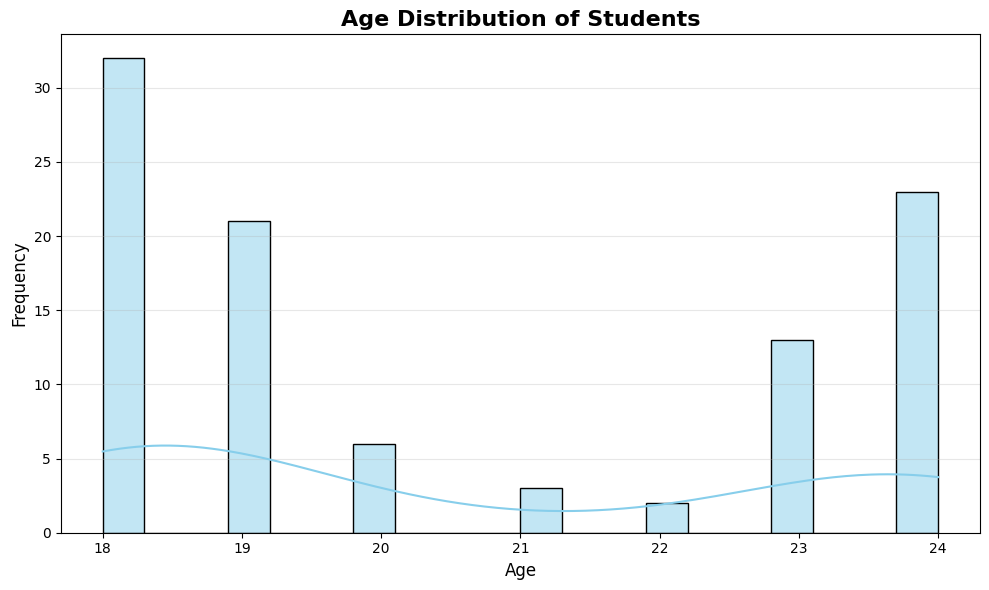

Age Statistics:
count    100.00000
mean      20.53000
std        2.49628
min       18.00000
25%       18.00000
50%       19.00000
75%       23.00000
max       24.00000
Name: age, dtype: float64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create age distribution graph
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', bins=20, kde=True, color='skyblue', edgecolor='black')
plt.title('Age Distribution of Students', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display age statistics
print("Age Statistics:")
print(df['age'].describe())

Gender Distribution:
gender
Female    75
Male      26
Name: count, dtype: int64


Gender Ratio (proportion):
gender
Female    0.742574
Male      0.257426
Name: count, dtype: float64


Male to Female Ratio: 0.35:1


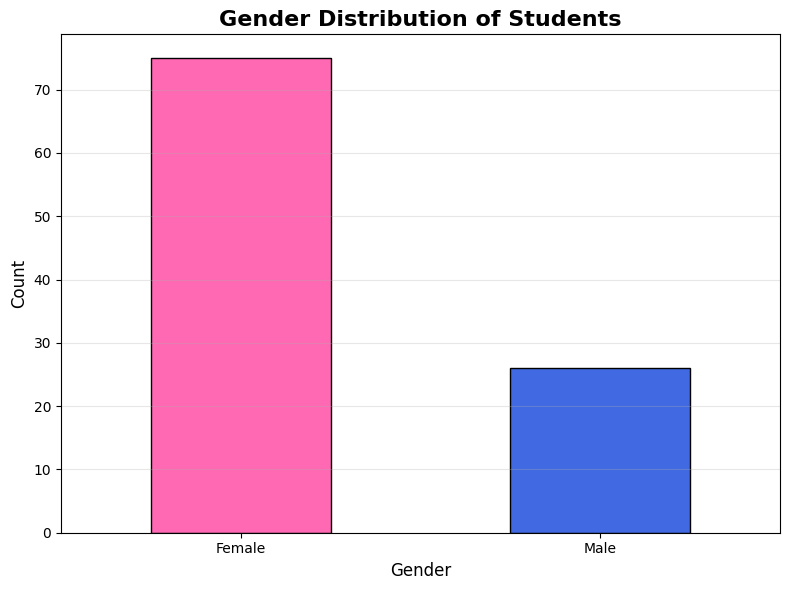

In [10]:
# Gender distribution and ratio
gender_counts = df['gender'].value_counts()
print("Gender Distribution:")
print(gender_counts)
print("\n")

# Calculate ratio
total = gender_counts.sum()
gender_ratio = gender_counts / total
print("Gender Ratio (proportion):")
print(gender_ratio)
print("\n")

# Calculate male to female ratio
male_count = gender_counts.get('Male', 0)
female_count = gender_counts.get('Female', 0)
if female_count > 0:
    male_female_ratio = male_count / female_count
    print(f"Male to Female Ratio: {male_female_ratio:.2f}:1")
else:
    print("No female count to calculate ratio")

# Visualize gender distribution
plt.figure(figsize=(8, 6))
colors = ['#FF69B4', '#4169E1']  # Pink for Female, Blue for Male
gender_counts.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Gender Distribution of Students', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()